# Chapter 1: Introduction to Cybersecurity

> "Security is not a product, but a process." Bruce Schneier

---

## Learning Objectives

After completing this chapter, you will be able to:

1. Define cybersecurity and explain why it matters to the modern digital economy.
2. Describe the CIA triad and the complementary DAD triad.
3. Define the core terms vulnerability, threat, exploit, and risk with precision.
4. Classify threat actors by motivation and capability.
5. Compute the Annualized Loss Expectancy (ALE) for a quantitative risk scenario.
6. Map controls to the functions of the NIST Cybersecurity Framework.

## Key Terms

- **CIA**: Confidentiality, Integrity, Availability.
- **DAD**: Disclosure, Alteration, Destruction (or Denial).
- **APT**: Advanced Persistent Threat.
- **NIST CSF**: National Institute of Standards and Technology Cybersecurity Framework.
- **ALE**: Annualized Loss Expectancy.

---

## 1.1 Why Cybersecurity Matters

Modern life depends on systems that store, transmit, and process information. When those systems fail
or are subverted, the consequences range from financial loss to threats against human life. The
Verizon Data Breach Investigations Report documents thousands of confirmed breaches each year and
consistently finds that a large share involve a human element such as stolen credentials, error, or
social engineering {cite}`verizon_dbir_2024`. Cybersecurity is therefore not only a technical field
but also an organizational and human one.

## 1.2 The CIA Triad

The CIA triad is the classical model for reasoning about security goals. **Confidentiality** ensures
that information is disclosed only to authorized parties. **Integrity** ensures that information is
not altered in an unauthorized or undetected manner. **Availability** ensures that information and
services are accessible when legitimate users need them. A useful exercise is to map every control you
encounter back to the triad: encryption primarily serves confidentiality, hashing and digital
signatures serve integrity, and redundancy and rate limiting serve availability.

The **DAD triad** is the attacker mirror image: Disclosure attacks confidentiality, Alteration attacks
integrity, and Destruction or Denial attacks availability. Thinking in both directions helps you
anticipate how a defensive gap translates into an offensive opportunity.

## 1.3 Core Terminology

A **vulnerability** is a weakness that can be exploited. A **threat** is a potential cause of an
unwanted incident. An **exploit** is the specific technique or code that takes advantage of a
vulnerability. **Risk** is the combination of the likelihood that a threat exploits a vulnerability
and the resulting impact. These distinctions matter: patching addresses vulnerabilities, threat
intelligence tracks threats, and risk management decides where to invest limited resources.

## 1.4 Threat Actors

Threat actors differ in motivation and capability. Script kiddies use existing tools with little
understanding. Hacktivists pursue ideological goals. Organized cybercriminals seek financial gain,
often through ransomware and fraud. Insiders abuse legitimate access. Nation-state actors, often
described as advanced persistent threats (APTs), pursue espionage or sabotage with significant
resources and patience. Matching defenses to the likely actor is central to a realistic threat model.

## 1.5 Why This Matters

Understanding these foundations lets you communicate clearly with both technical and non-technical
stakeholders, and it gives you a vocabulary that the rest of this book builds upon. Every later
chapter, from cryptography to incident response, is ultimately about protecting one or more legs of
the CIA triad against one or more classes of threat actor.

## 1.6 News in Focus

In 2021, the operator of a major U.S. fuel pipeline halted operations after a ransomware incident
attributed to a criminal group, leading to fuel supply disruptions across parts of the eastern United
States. The incident illustrates how an availability attack on information systems can produce
physical, economic, and societal consequences far beyond the breached network.

## 1.7 Worked Numerical Example: Annualized Loss Expectancy

Risk can be quantified. The Single Loss Expectancy (SLE) is the asset value multiplied by the exposure
factor. The Annualized Loss Expectancy is the SLE multiplied by the Annual Rate of Occurrence (ARO):

$$ALE = SLE \times ARO = (AssetValue \times ExposureFactor) \times ARO$$

If a database is valued at USD 500,000, a breach would destroy 40 percent of that value, and such a
breach is expected once every five years (ARO = 0.2), then the ALE is computed in the code cell below.


In [1]:
# ALE calculation for the worked example
asset_value = 500_000      # USD
exposure_factor = 0.40     # fraction of value lost per incident
aro = 0.2                  # annual rate of occurrence (once per 5 years)

sle = asset_value * exposure_factor
ale = sle * aro

print(f"Single Loss Expectancy (SLE): ${sle:,.2f}")
print(f"Annualized Loss Expectancy (ALE): ${ale:,.2f}")

# Decision rule: a control costing less than the ALE it removes is worth considering.
control_cost = 25_000
print(f"\nProposed annual control cost: ${control_cost:,.2f}")
print("Control is cost-justified" if control_cost < ale else "Control is not cost-justified")


Single Loss Expectancy (SLE): $200,000.00
Annualized Loss Expectancy (ALE): $40,000.00

Proposed annual control cost: $25,000.00
Control is cost-justified


## 1.7b Visualizing How the Core Terms Relate

The vocabulary of this chapter forms a chain. A **flaw** or loophole is a weakness in design or
implementation. When that weakness can be acted on it is a **vulnerability**, which resides in the system's
**attack surface**. A **threat** is an actor or event with the potential to exploit the vulnerability;
when the threat acts it launches an **attack**, and a successful attack results in **exploitation**. The
chance that this chain completes and causes harm is **risk**. The figure below, generated in code, lays out
that relationship so the terms are seen together rather than as isolated definitions.

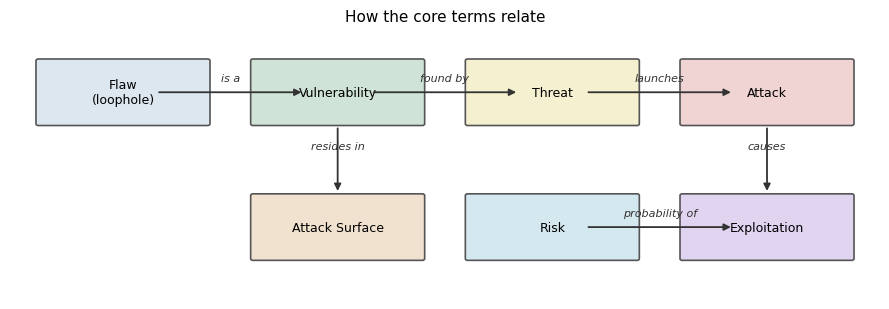

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.axis("off")

# node label -> (x, y)
nodes = {
    "Flaw\n(loophole)": (0.5, 2.3),
    "Vulnerability":    (2.4, 2.3),
    "Attack Surface":   (2.4, 0.8),
    "Threat":           (4.3, 2.3),
    "Attack":           (6.2, 2.3),
    "Exploitation":     (6.2, 0.8),
    "Risk":             (4.3, 0.8),
}
colors = {
    "Flaw\n(loophole)": "#dde7f0", "Vulnerability": "#cfe3d6", "Attack Surface": "#f0e2cf",
    "Threat": "#f5f0cf", "Attack": "#f0d4d4", "Exploitation": "#e0d4f0", "Risk": "#d4e8f0",
}
w, h = 1.5, 0.7
for label, (x, y) in nodes.items():
    ax.add_patch(mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
                 boxstyle="round,pad=0.02", linewidth=1.2,
                 edgecolor="#555", facecolor=colors[label]))
    ax.text(x, y, label, ha="center", va="center", fontsize=9)

def arrow(a, b, text):
    (x1, y1), (x2, y2) = nodes[a], nodes[b]
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color="#333", lw=1.3,
                                shrinkA=26, shrinkB=26))
    ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.12, text, ha="center",
            fontsize=8, color="#333", style="italic")

arrow("Flaw\n(loophole)", "Vulnerability", "is a")
arrow("Vulnerability", "Threat", "found by")
arrow("Threat", "Attack", "launches")
arrow("Attack", "Exploitation", "causes")
arrow("Risk", "Exploitation", "probability of")
arrow("Vulnerability", "Attack Surface", "resides in")

ax.set_xlim(-0.5, 7.2)
ax.set_ylim(0.0, 3.0)
ax.set_title("How the core terms relate", fontsize=11)
plt.tight_layout()
plt.show()


## 1.8 The NIST Cybersecurity Framework

The NIST CSF organizes security activity into a small set of functions: Govern, Identify, Protect,
Detect, Respond, and Recover {cite}`nist_csf_2024`. The framework is deliberately outcome-based rather
than prescriptive, which lets organizations of different sizes and sectors adopt it. Throughout this
book it is worth asking which function a given technique supports.

## 1.9 Review Questions (MCQ)

**Q1.** Encrypting data at rest primarily protects which property?
A. Availability  B. Integrity  C. Confidentiality  D. Non-repudiation

**Q2.** A weakness that could be exploited is best described as a:
A. Threat  B. Vulnerability  C. Exploit  D. Risk

**Q3.** Which actor is characterized by long-term, well-resourced espionage?
A. Script kiddie  B. Hacktivist  C. Advanced persistent threat  D. Insider

*Answers: Q1 C, Q2 B, Q3 C.*

## 1.10 Lab Assignment

Using a personal or instructor-provided test machine, inventory five services that are running and
classify each by the CIA property it most needs to protect. Document one realistic threat against each
and one control that addresses it.

## References

```{bibliography}
:filter: docname in docnames
```
